# train_layoutlmv3 SER fine-tuning 

Labels : O / B-KEY / I-KEY / B-VAL / I-VAL  
Model  : microsoft/layoutlmv3-base  
Dataset: custom KVP dataset (funsd_plus format)  
Device : RTX 3070 (8 GB VRAM, CUDA)

In [1]:
%pip install transformers datasets seqeval evaluate --upgrade

   ---------------------------------------- 0.0/10.8 MB ? eta -:--:--
   ---------------------------------------  10.7/10.8 MB 67.2 MB/s eta 0:00:01
   ---------------------------------------- 10.8/10.8 MB 61.2 MB/s  0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.8.1
    Uninstalling transformers-5.8.1:
      Successfully uninstalled transformers-5.8.1
Note: you may need to restart the kernel to use updated packages.


In [2]:
import json
import warnings
from pathlib import Path
from datasets import Dataset
from PIL import Image

DATA_ROOT = Path(r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\dataset\funsd_plus")

def load_ocr_words(ocr_path):
    with open(ocr_path, encoding="utf-8") as f:
        data = json.load(f)
    if "words" in data:
        return data["words"]
    if "pages" in data:
        result = []
        for page in data["pages"]:
            for w in page.get("words", []):
                if w.get("text", "").strip():
                    result.append({"text": w["text"], "bbox": w["bbox"]})
        return result
    if "form" in data:
        result = []
        for block in data["form"]:
            for w in block.get("words", []):
                if w.get("text", "").strip():
                    result.append({"text": w["text"], "bbox": w["box"]})
        return result
    raise ValueError(f"Unknown OCR format in {ocr_path}: keys={list(data.keys())}")


def compute_iou(box_a, box_b):
    ix0 = max(box_a[0], box_b[0])
    iy0 = max(box_a[1], box_b[1])
    ix1 = min(box_a[2], box_b[2])
    iy1 = min(box_a[3], box_b[3])

    inter_area = max(0, ix1 - ix0) * max(0, iy1 - iy0)
    if inter_area == 0:
        return 0.0

    area_a     = max(0, box_a[2] - box_a[0]) * max(0, box_a[3] - box_a[1])
    area_b     = max(0, box_b[2] - box_b[0]) * max(0, box_b[3] - box_b[1])
    union_area = area_a + area_b - inter_area
    return inter_area / union_area if union_area > 0 else 0.0


def assign_labels(words, kvps, iou_thresh=0.3):
    label2id = {"O": 0, "B-KEY": 1, "I-KEY": 2, "B-VAL": 3, "I-VAL": 4}

    regions = []
    for kvp in kvps:
        regions.append((kvp["key"]["bbox"], "KEY"))
        if kvp.get("value") and kvp["value"].get("bbox"):
            regions.append((kvp["value"]["bbox"], "VAL"))

    labels        = []
    last_word_idx = {}

    for wi, word in enumerate(words):
        best_iou = 0.0
        best_idx = -1
        for idx, (rbox, _role) in enumerate(regions):
            iou = compute_iou(word["bbox"], rbox)
            if iou > best_iou:
                best_iou = iou
                best_idx = idx

        if best_iou < iou_thresh or best_idx < 0:
            labels.append(label2id["O"])
        else:
            role = regions[best_idx][1]
            # B starts a new span, I continues if the previous word matched the same region
            tag = f"I-{role}" if last_word_idx.get(best_idx) == wi - 1 else f"B-{role}"
            labels.append(label2id[tag])
            last_word_idx[best_idx] = wi

    return labels


def build_record(image_path, gts_path, ocr_path):
    image = Image.open(image_path).convert("RGB")
    img_w, img_h = image.size

    with open(gts_path, encoding="utf-8") as f:
        gts  = json.load(f)
    kvps     = gts.get("kvps_list", [])
    words    = load_ocr_words(ocr_path)
    ner_tags = assign_labels(words, kvps)

    tokens, bboxes = [], []
    for w in words:
        x0, y0, x1, y1 = w["bbox"]
        # fix annotations where corners are stored in the wrong order
        x0, x1 = min(x0, x1), max(x0, x1)
        y0, y1 = min(y0, y1), max(y0, y1)
        tokens.append(w["text"])
        bboxes.append([
            int(min(max(x0 / img_w * 1000, 0), 1000)),
            int(min(max(y0 / img_h * 1000, 0), 1000)),
            int(min(max(x1 / img_w * 1000, 0), 1000)),
            int(min(max(y1 / img_h * 1000, 0), 1000)),
        ])

    return {"image": image, "tokens": tokens, "bboxes": bboxes, "ner_tags": ner_tags}


def build_split(split, data_root=DATA_ROOT):
    data_root  = Path(data_root)
    images_dir = data_root / split / "images"
    gts_dir    = data_root / split / "gts"
    ocr_dir    = data_root / split / "ocr"

    records, skipped = [], 0

    for img_path in sorted(images_dir.glob("*.png")):
        stem     = img_path.stem
        gts_path = gts_dir / f"{stem}.json"
        ocr_path = ocr_dir / f"{stem}.json"

        if not gts_path.exists():
            warnings.warn(f"[{split}] Missing GTS for {stem}, skipping")
            skipped += 1
            continue
        if not ocr_path.exists():
            warnings.warn(f"[{split}] Missing OCR for {stem}, skipping")
            skipped += 1
            continue

        try:
            records.append(build_record(img_path, gts_path, ocr_path))
        except Exception as e:
            warnings.warn(f"[{split}] Error processing {stem}: {e}, skipping")
            skipped += 1

    print(f"[{split}] loaded {len(records)} records, skipped {skipped}")
    return records


train_records = build_split("train")
test_records  = build_split("test")

train_dataset = Dataset.from_list(train_records)
eval_dataset  = Dataset.from_list(test_records)

print(len(train_dataset), len(eval_dataset))
print("DATA_ROOT exists:", DATA_ROOT.exists())
print("train images dir exists:", (DATA_ROOT / "train" / "images").exists())
print("train records count:", len(train_records))
print("test records count:", len(test_records))


[train] loaded 1026 records, skipped 0
[test] loaded 113 records, skipped 0
1026 113
DATA_ROOT exists: True
train images dir exists: True
train records count: 1026
test records count: 113


Saved to C:\Users\Admin\OneDrive - UTS\Work\School work\UTS\Autumn 2026\DeepLearning\A3 report\bio_label_sample.png


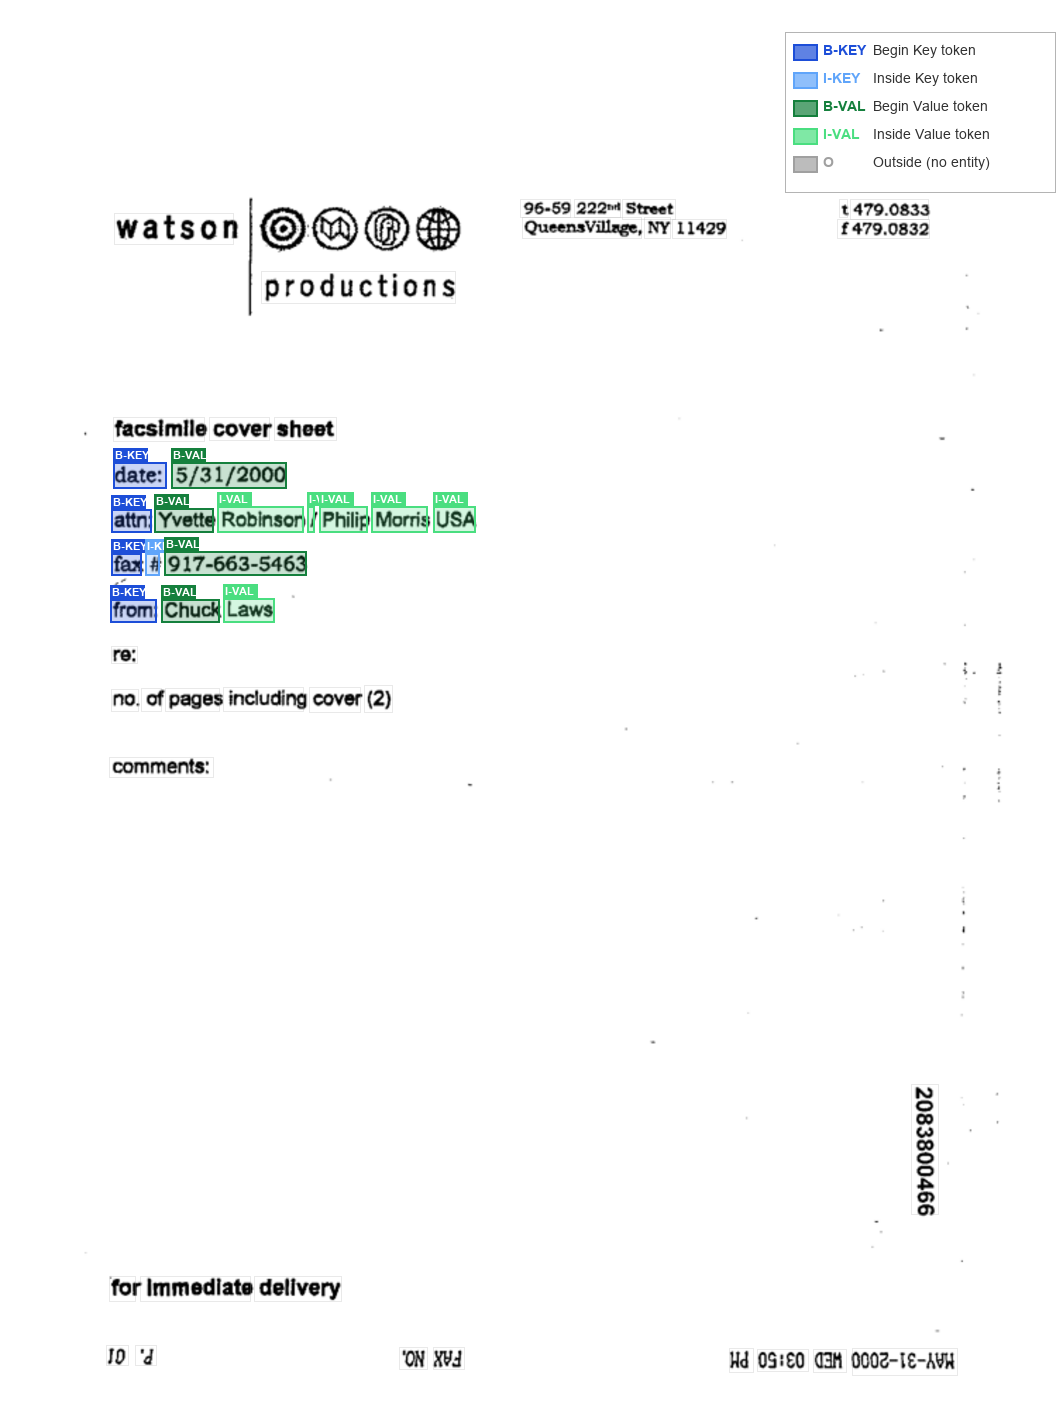

In [3]:
from PIL import Image, ImageDraw, ImageFont
import json
import os

img_path = r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\dataset\funsd_plus\test\images\000000.png"
ocr_path = r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\dataset\funsd_plus\test\ocr\000000.json"
gts_path = r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\dataset\funsd_plus\test\gts\000000.json"
out_path = r"C:\Users\Admin\OneDrive - UTS\Work\School work\UTS\Autumn 2026\DeepLearning\A3 report\bio_label_sample.png"

with open(ocr_path) as f:
    ocr_data = json.load(f)

if "pages" in ocr_data:
    words = ocr_data["pages"][0]["words"]
else:
    words = ocr_data["words"]

with open(gts_path) as f:
    kvps = json.load(f)["kvps_list"]

def coverage(wb, eb):
    ix0, iy0 = max(wb[0], eb[0]), max(wb[1], eb[1])
    ix1, iy1 = min(wb[2], eb[2]), min(wb[3], eb[3])
    if ix1 <= ix0 or iy1 <= iy0:
        return 0.0
    return (ix1 - ix0) * (iy1 - iy0) / max((wb[2] - wb[0]) * (wb[3] - wb[1]), 1)

# assign BIO labels: O=0, B-KEY=1, I-KEY=2, B-VAL=3, I-VAL=4
word_labels = [0] * len(words)
for kvp in kvps:
    if kvp["type"] != "kvp":
        continue
    kb = kvp["key"].get("bbox")
    vb = kvp["value"].get("bbox")
    km = [i for i, w in enumerate(words) if kb and coverage(w["bbox"], kb) >= 0.3]
    vm = [i for i, w in enumerate(words) if vb and coverage(w["bbox"], vb) >= 0.3]
    for j, idx in enumerate(km):
        word_labels[idx] = 1 if j == 0 else 2
    for j, idx in enumerate(vm):
        word_labels[idx] = 3 if j == 0 else 4

STYLE = {
    0: {"outline": (160, 160, 160), "fill": (160, 160, 160,  0), "tag": None},
    1: {"outline": ( 29,  78, 216), "fill": ( 29,  78, 216, 60), "tag": "B-KEY"},
    2: {"outline": ( 96, 165, 250), "fill": ( 96, 165, 250, 60), "tag": "I-KEY"},
    3: {"outline": ( 21, 128,  61), "fill": ( 21, 128,  61, 60), "tag": "B-VAL"},
    4: {"outline": ( 74, 222, 128), "fill": ( 74, 222, 128, 60), "tag": "I-VAL"},
}

font_tag  = ImageFont.truetype(r"C:/Windows/Fonts/arialbd.ttf", 11)
font_leg  = ImageFont.truetype(r"C:/Windows/Fonts/arial.ttf",   14)
font_legb = ImageFont.truetype(r"C:/Windows/Fonts/arialbd.ttf", 14)

img  = Image.open(img_path).convert("RGB")
draw = ImageDraw.Draw(img, "RGBA")

for i, w in enumerate(words):
    lbl = word_labels[i]
    s   = STYLE[lbl]
    x0, y0, x1, y1 = w["bbox"]
    if lbl == 0:
        draw.rectangle([x0, y0, x1, y1], outline=s["outline"] + (60,), width=1)
    else:
        draw.rectangle([x0, y0, x1, y1], fill=s["fill"], outline=s["outline"], width=2)
        tag = s["tag"]
        tw  = len(tag) * 6
        tx, ty = x0, max(y0 - 14, 0)
        draw.rectangle([tx, ty, tx + tw + 4, ty + 13], fill=s["outline"])
        draw.text((tx + 2, ty + 1), tag, fill="white", font=font_tag)

legend = [
    (1, "B-KEY", "Begin Key token"),
    (2, "I-KEY", "Inside Key token"),
    (3, "B-VAL", "Begin Value token"),
    (4, "I-VAL", "Inside Value token"),
    (0, "O",     "Outside (no entity)"),
]
lx = img.width - 270
ly = 40
draw.rectangle(
    [lx - 8, ly - 8, lx + 262, ly + len(legend) * 28 + 12],
    fill=(255, 255, 255, 235), outline=(180, 180, 180), width=1,
)
for lbl, short, desc in legend:
    c = STYLE[lbl]["outline"]
    draw.rectangle([lx, ly + 4, lx + 24, ly + 20], fill=c + (180,), outline=c, width=2)
    draw.text((lx + 30, ly + 2), short, fill=c,           font=font_legb)
    draw.text((lx + 80, ly + 2), desc,  fill=(50, 50, 50), font=font_leg)
    ly += 28

os.makedirs(os.path.dirname(out_path), exist_ok=True)
img.save(out_path, dpi=(150, 150))
print(f"Saved to {out_path}")
display(img)


In [4]:
# label quality audit on 10 sampled training documents, comparing assigned BIO labels to expected labels based on IoU with GT key/value boxes. This helps estimate label noise before training.
import random

random.seed(36)

IOU_THRESH = 0.3
ID2LABEL   = {0: "O", 1: "B-KEY", 2: "I-KEY", 3: "B-VAL", 4: "I-VAL"}

audit_images_dir = DATA_ROOT / "train" / "images"
audit_gts_dir    = DATA_ROOT / "train" / "gts"
audit_ocr_dir    = DATA_ROOT / "train" / "ocr"

all_stems    = sorted(p.stem for p in audit_images_dir.glob("*.png"))
sample_stems = random.sample(all_stems, 10)

global_total       = 0
global_mislabelled = 0

for stem in sample_stems:
    with open(audit_gts_dir / f"{stem}.json", encoding="utf-8") as f:
        gts  = json.load(f)
    kvps = gts.get("kvps_list", [])

    words    = load_ocr_words(audit_ocr_dir / f"{stem}.json")
    pred_ids = assign_labels(words, kvps)

    key_bboxes = [kvp["key"]["bbox"] for kvp in kvps if kvp.get("key") and kvp["key"].get("bbox")]
    val_bboxes = [
        kvp["value"]["bbox"] for kvp in kvps
        if kvp.get("value") and kvp["value"].get("bbox")
    ]

    print(f"\n{'='*70}")
    print(f"DOC: {stem}")
    print(f"{'Token':<25} {'Label':<8} {'Expected':<10} {'Match'}")
    print(f"{'-'*25} {'-'*8} {'-'*10} {'-'*15}")

    doc_total       = 0
    doc_mislabelled = 0

    for word, pred_id in zip(words, pred_ids):
        token     = word["text"]
        wbox      = word["bbox"]
        label_str = ID2LABEL[pred_id]

        best_key_iou = max((compute_iou(wbox, kb) for kb in key_bboxes), default=0.0)
        best_val_iou = max((compute_iou(wbox, vb) for vb in val_bboxes), default=0.0)

        if best_key_iou >= IOU_THRESH:
            expected = "KEY"
        elif best_val_iou >= IOU_THRESH:
            expected = "VAL"
        else:
            expected = "O"

        pred_role = label_str.split("-", 1)[-1] if "-" in label_str else label_str
        match     = pred_role == expected
        flag      = "" if match else "*** MISMATCH"

        display_token = (token[:22] + "..") if len(token) > 24 else token
        print(f"[{stem[:8]}] {display_token:<25} {label_str:<8} {expected:<10} {flag}")

        doc_total += 1
        if not match:
            doc_mislabelled += 1

    pct = (doc_mislabelled / doc_total * 100) if doc_total else 0.0
    print(f"\n  Total tokens: {doc_total}  |  Mislabelled: {doc_mislabelled} ({pct:.1f}%)")

    global_total       += doc_total
    global_mislabelled += doc_mislabelled

global_rate = (global_mislabelled / global_total * 100) if global_total else 0.0
print(f"\n{'='*70}")
print(f"GLOBAL SUMMARY (10 sampled docs)")
print(f"  Total tokens      : {global_total}")
print(f"  Total mislabelled : {global_mislabelled}")
print(f"  Overall mislabel rate: {global_rate:.1f}%")

if global_rate > 15:
    print("WARNING: label noise above 15% -- hyperparameter tuning will not improve F1")
else:
    print("Label quality OK -- proceed to training")



DOC: 000673
Token                     Label    Expected   Match
------------------------- -------- ---------- ---------------
[000673] PHILIP                    O        O          
[000673] MORRIS                    O        O          
[000673] RESEARCH                  O        O          
[000673] CENTER                    O        O          
[000673] CR                        O        O          
[000673] New                       O        O          
[000673] [X]                       O        O          
[000673] Known                     O        O          
[000673] [                         O        O          
[000673] 1392                      O        O          
[000673] Emp.                      B-KEY    KEY        
[000673] Formula                   I-KEY    KEY        
[000673] C,                        O        O          
[000673] 1H,                       O        O          
[000673] ,                         O        O          
[000673] NBr                     

{'image': Image(mode=None, decode=True), 'tokens': List(Value('string')), 'bboxes': List(List(Value('int64'))), 'ner_tags': List(Value('int64'))}


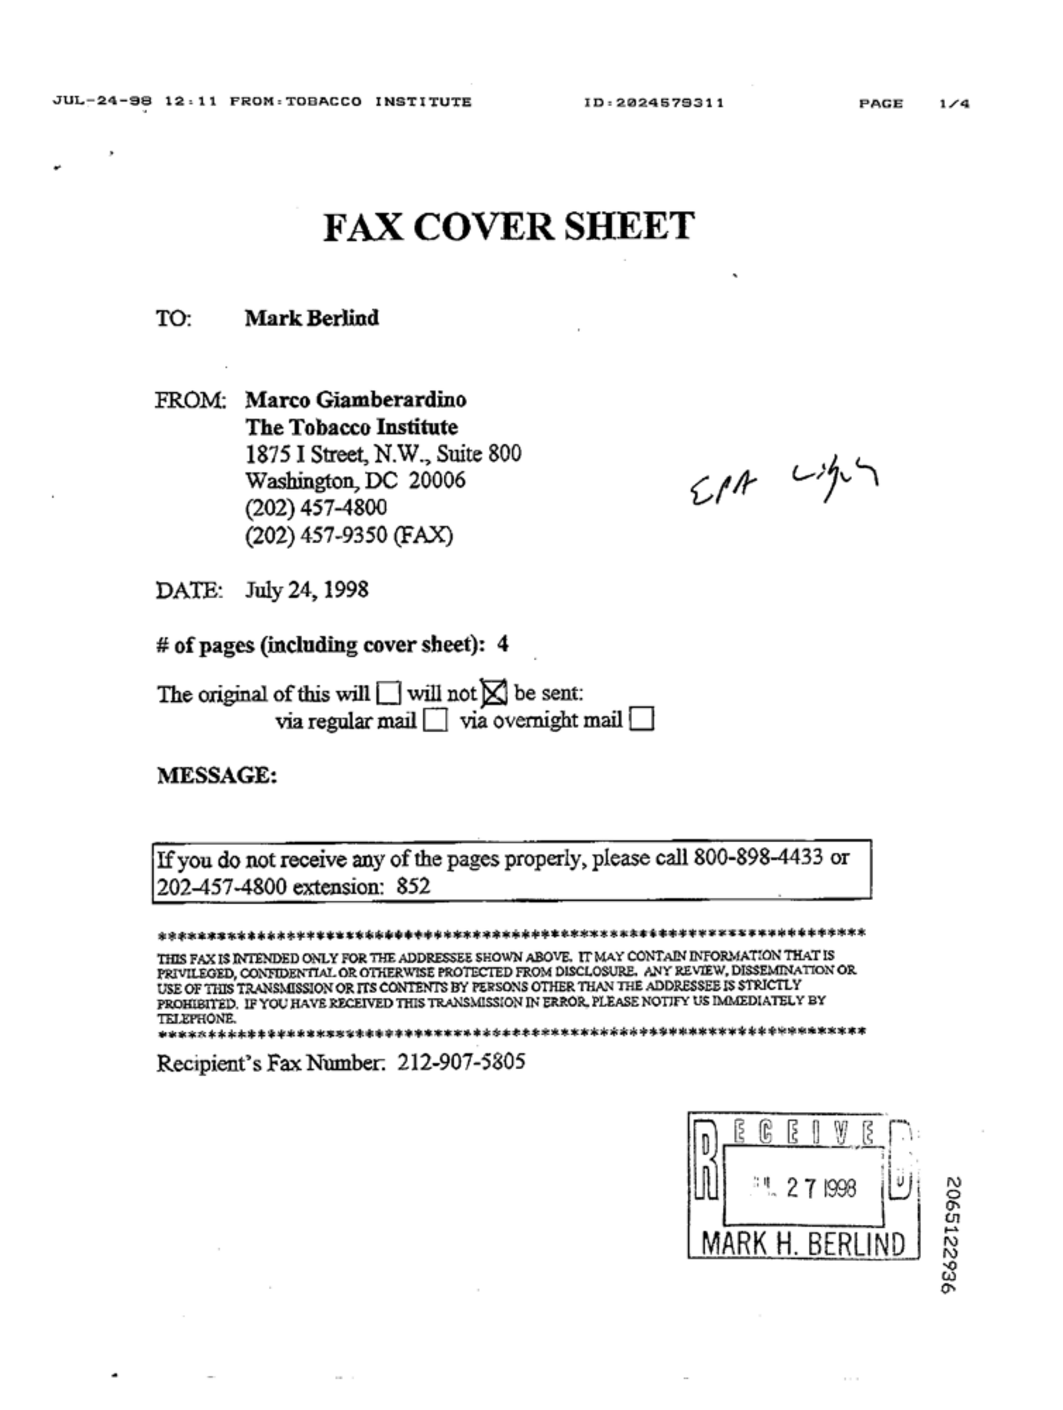

tokens   : ['JUL-24-98', '12:11', 'FROM:', 'TOBACCO', 'INSTITUTE', 'ID:', '2024579311', 'PAGE', '1/4', 'FAX', 'COVER', 'SHEET', 'TO:', 'Mark', 'Berlind']
bboxes   : [[46, 65, 139, 78], [151, 65, 203, 78], [212, 65, 262, 78], [266, 65, 336, 78], [349, 65, 441, 78]]
ner_tags : [0, 0, 1, 3, 4, 1, 3, 1, 3, 0, 0, 0, 1, 3, 4]


In [5]:
print(train_dataset.features)

example = train_dataset[0]
display(example["image"])
print("tokens   :", example["tokens"][:15])
print("bboxes   :", example["bboxes"][:5])
print("ner_tags :", example["ner_tags"][:15])


In [6]:
from transformers import AutoProcessor

# disable built-in Tesseract OCR since we supply our own tokens
processor = AutoProcessor.from_pretrained("microsoft/layoutlmv3-base", apply_ocr=False)

label_list = ["O", "B-KEY", "I-KEY", "B-VAL", "I-VAL"]
id2label   = {i: lbl for i, lbl in enumerate(label_list)}
label2id   = {lbl: i for i, lbl in enumerate(label_list)}

print("id2label:", id2label)
print("label2id:", label2id)


id2label: {0: 'O', 1: 'B-KEY', 2: 'I-KEY', 3: 'B-VAL', 4: 'I-VAL'}
label2id: {'O': 0, 'B-KEY': 1, 'I-KEY': 2, 'B-VAL': 3, 'I-VAL': 4}


In [7]:
from datasets import Array2D, Array3D, Features, Sequence, Value


def prepare_examples(examples):
    encoding = processor(
        examples["image"],
        examples["tokens"],
        boxes=examples["bboxes"],
        word_labels=examples["ner_tags"],
        truncation=True,
        padding="max_length",
        return_tensors=None,
    )
    # convert to list so Arrow can serialize (Arrow cannot handle raw numpy arrays)
    encoding["pixel_values"] = [
        pv.tolist() if hasattr(pv, "tolist") else pv
        for pv in encoding["pixel_values"]
    ]
    return encoding


# tell Arrow the fixed shapes before mapping
features = Features({
    "pixel_values":   Array3D(dtype="float32", shape=(3, 224, 224)),
    "input_ids":      Sequence(feature=Value(dtype="int64")),
    "attention_mask": Sequence(Value(dtype="int64")),
    "bbox":           Array2D(dtype="int64", shape=(512, 4)),
    "labels":         Sequence(feature=Value(dtype="int64")),
})

raw_columns = ["image", "tokens", "bboxes", "ner_tags"]

train_dataset = train_dataset.map(
    prepare_examples,
    batched=True,
    remove_columns=raw_columns,
    features=features,
)
eval_dataset = eval_dataset.map(
    prepare_examples,
    batched=True,
    remove_columns=raw_columns,
    features=features,
)

print("train features:", train_dataset.features)
print("eval  features:", eval_dataset.features)


Map:   0%|          | 0/1026 [00:00<?, ? examples/s]

Map:   0%|          | 0/113 [00:00<?, ? examples/s]

train features: {'pixel_values': Array3D(shape=(3, 224, 224), dtype='float32'), 'input_ids': List(Value('int64')), 'attention_mask': List(Value('int64')), 'bbox': Array2D(shape=(512, 4), dtype='int64'), 'labels': List(Value('int64'))}
eval  features: {'pixel_values': Array3D(shape=(3, 224, 224), dtype='float32'), 'input_ids': List(Value('int64')), 'attention_mask': List(Value('int64')), 'bbox': Array2D(shape=(512, 4), dtype='int64'), 'labels': List(Value('int64'))}


In [8]:
train_dataset.set_format("torch")
eval_dataset.set_format("torch")

sample = train_dataset[0]
for k, v in sample.items():
    print(f"{k:20s}: {v.shape}")


pixel_values        : torch.Size([3, 224, 224])
input_ids           : torch.Size([512])
attention_mask      : torch.Size([512])
bbox                : torch.Size([512, 4])
labels              : torch.Size([512])


In [9]:
import evaluate
import numpy as np

metric = evaluate.load("seqeval")


def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=2)

    # skip -100 positions to get one prediction per real OCR word
    true_predictions = [
        [label_list[pred] for pred, lbl in zip(preds, lbls) if lbl != -100]
        for preds, lbls in zip(predictions, labels)
    ]
    true_labels = [
        [label_list[lbl] for pred, lbl in zip(preds, lbls) if lbl != -100]
        for preds, lbls in zip(predictions, labels)
    ]

    results = metric.compute(predictions=true_predictions, references=true_labels)
    per_class = {
        f"{entity}_{metric_name}": metric_val
        for entity, value in results.items()
        if isinstance(value, dict)
        for metric_name, metric_val in value.items()
    }

    return {"precision": results["overall_precision"],
            "recall":    results["overall_recall"],
            "f1":        results["overall_f1"],
            "accuracy":  results["overall_accuracy"],
            **per_class}


In [10]:
from transformers import LayoutLMv3ForTokenClassification

model = LayoutLMv3ForTokenClassification.from_pretrained(
    "microsoft/layoutlmv3-base",
    id2label=id2label,
    label2id=label2id,
)


Loading weights:   0%|          | 0/212 [00:00<?, ?it/s]

[transformers] LayoutLMv3ForTokenClassification LOAD REPORT from: microsoft/layoutlmv3-base
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [11]:
from collections import Counter

# count tokens per class, skip -100 padding positions
num_labels   = len(label_list)
label_counts = Counter()
for item in train_dataset:
    for label in item["labels"].tolist():
        if label != -100:
            label_counts[int(label)] += 1

class_counts = [label_counts[i] for i in range(num_labels)]
print("Class counts:")
for i, (name, count) in enumerate(zip(label_list, class_counts)):
    print(f"  [{i}] {name:<8}: {count:,}")


Class counts:
  [0] O       : 138,479
  [1] B-KEY   : 7,378
  [2] I-KEY   : 1,433
  [3] B-VAL   : 6,328
  [4] I-VAL   : 1,428


In [ ]:
import torch
import torch.nn as nn
from transformers import TrainingArguments, Trainer
from transformers.data.data_collator import default_data_collator

# inverse frequency weights: rare classes get higher weight
# formula: total / (num_classes * class_count)
total_tokens  = sum(class_counts)
num_classes   = len(class_counts)
class_weights = torch.tensor(
    [total_tokens / (num_classes * c) for c in class_counts],
    dtype=torch.float32,
)
print("Class weights:", class_weights)


class WeightedLossTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(
            weight=class_weights.to(logits.device),  # move weights to same device as logits
            ignore_index=-100,
        )
        loss = loss_fct(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


training_args = TrainingArguments(
    output_dir="layoutlmv3-finetuned-kvp-100ep",
    num_train_epochs=100,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=2,
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    weight_decay=0.01,
    fp16=True,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=5,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    logging_strategy="epoch",
    dataloader_num_workers=0,  # Windows multiprocessing deadlock fix
    seed=36,
)

trainer = WeightedLossTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    processing_class=processor,
    data_collator=default_data_collator,
    compute_metrics=compute_metrics,
)


Class weights: tensor([ 0.2239,  4.2029, 21.6394,  4.9003, 21.7151])


In [ ]:
trainer.train()

Step,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy,Key Precision,Key Recall,Key F1,Key Number,Val Precision,Val Recall,Val F1,Val Number
200,No log,0.397767,0.353134,0.749208,0.480016,0.832892,0.390012,0.774498,0.518782,847,0.315947,0.719945,0.439167,732
400,1.224194,0.359995,0.422673,0.765041,0.544512,0.875500,0.439136,0.792208,0.565053,847,0.403759,0.733607,0.520854,732
600,0.582157,0.349978,0.410615,0.798607,0.542366,0.869695,0.446906,0.809917,0.575987,847,0.374349,0.785519,0.507055,732
800,0.440649,0.330376,0.417965,0.798607,0.548738,0.870991,0.454784,0.819362,0.584914,847,0.380282,0.774590,0.510121,732
1000,0.440649,0.401124,0.562314,0.837239,0.672774,0.922336,0.578947,0.844156,0.686840,847,0.543907,0.829235,0.656926,732
1200,0.356920,0.352760,0.460910,0.821406,0.590485,0.889252,0.486851,0.852420,0.619742,847,0.432006,0.785519,0.557441,732
1400,0.279898,0.359981,0.493213,0.828372,0.618294,0.903286,0.530191,0.850059,0.653061,847,0.454405,0.803279,0.580454,732
1600,0.239642,0.502022,0.615421,0.834072,0.708255,0.936707,0.628521,0.842975,0.720121,847,0.600598,0.823770,0.694700,732
1800,0.217294,0.377539,0.573536,0.837239,0.680742,0.924252,0.617823,0.851240,0.715988,847,0.528120,0.821038,0.642781,732
2000,0.217294,0.408407,0.541649,0.827739,0.654810,0.917545,0.565811,0.832349,0.673674,847,0.515853,0.822404,0.634018,732


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=25700, training_loss=0.06358563123046192, metrics={'train_runtime': 13080.8538, 'train_samples_per_second': 7.844, 'train_steps_per_second': 1.965, 'total_flos': 2.70454234576896e+16, 'train_loss': 0.06358563123046192, 'epoch': 100.0})

In [17]:
import os
from transformers import LayoutLMv3ForTokenClassification, AutoProcessor

best_ckpt = r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\layoutlmv3-finetuned-kvp-v3\checkpoint-25600"
save_dir_v3    = "layoutlmv3-finetuned-kvp-v3/best_model"
save_dir_100ep = "layoutlmv3-finetuned-kvp-100ep/best_model"
os.makedirs(save_dir_v3, exist_ok=True)
os.makedirs(save_dir_100ep, exist_ok=True)

model     = LayoutLMv3ForTokenClassification.from_pretrained(best_ckpt)
processor = AutoProcessor.from_pretrained(best_ckpt)

# save weights and config together so both folders are self-contained
model.save_pretrained(save_dir_v3)
processor.save_pretrained(save_dir_v3)
model.save_pretrained(save_dir_100ep)
processor.save_pretrained(save_dir_100ep)

print(f"Saved to {save_dir_v3}")
print(f"Saved to {save_dir_100ep}")


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to layoutlmv3-finetuned-kvp-v3/best_model
Saved to layoutlmv3-finetuned-kvp-100ep/best_model


In [ ]:
# run this cell after any kernel restart to skip retraining

import json
import warnings
import torch
from pathlib import Path
from PIL import Image
from transformers import AutoModelForTokenClassification, AutoProcessor

SAVE_DIR  = "layoutlmv3-finetuned-kvp-v3/best_model"
DATA_ROOT = Path(r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\dataset\funsd_plus")

device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = AutoModelForTokenClassification.from_pretrained(SAVE_DIR)
processor = AutoProcessor.from_pretrained(SAVE_DIR, apply_ocr=False)
model.eval()
model.to(device)

label_list = ["O", "B-KEY", "I-KEY", "B-VAL", "I-VAL"]
id2label   = {i: lbl for i, lbl in enumerate(label_list)}
label2id   = {lbl: i  for i, lbl in enumerate(label_list)}

def _load_ocr_words(ocr_path):
    with open(ocr_path, encoding="utf-8") as f:
        data = json.load(f)
    if "words" in data:
        return data["words"]
    words = []
    for page in data.get("pages", []):
        for w in page.get("words", []):
            if w.get("text", "").strip():
                words.append({"text": w["text"], "bbox": w["bbox"]})
    return words

def _build_test_record(img_path, ocr_path):
    image        = Image.open(img_path).convert("RGB")
    img_w, img_h = image.size
    words        = _load_ocr_words(ocr_path)
    tokens, bboxes = [], []
    for w in words:
        x0, y0, x1, y1 = w["bbox"]
        x0, x1 = min(x0, x1), max(x0, x1)
        y0, y1 = min(y0, y1), max(y0, y1)
        tokens.append(w["text"])
        bboxes.append([
            int(min(max(x0 / img_w * 1000, 0), 1000)),
            int(min(max(y0 / img_h * 1000, 0), 1000)),
            int(min(max(x1 / img_w * 1000, 0), 1000)),
            int(min(max(y1 / img_h * 1000, 0), 1000)),
        ])
    return {"image": image, "tokens": tokens, "bboxes": bboxes}

test_images_dir = DATA_ROOT / "test" / "images"
test_ocr_dir    = DATA_ROOT / "test" / "ocr"
test_records = []
for img_path in sorted(test_images_dir.glob("*.png")):
    ocr_path = test_ocr_dir / f"{img_path.stem}.json"
    if ocr_path.exists():
        try:
            test_records.append(_build_test_record(img_path, ocr_path))
        except Exception as e:
            warnings.warn(f"Skipped {img_path.stem}: {e}")

print(f"Model   : {SAVE_DIR}")
print(f"Device  : {device}")
print(f"Labels  : {id2label}")
print(f"test_records: {len(test_records)} loaded")


Loading weights:   0%|          | 0/214 [00:00<?, ?it/s]

Model   : layoutlmv3-finetuned-kvp-100ep/best_model
Device  : cuda
Labels  : {0: 'O', 1: 'B-KEY', 2: 'I-KEY', 3: 'B-VAL', 4: 'I-VAL'}
test_records: 113 loaded


In [16]:
# results from checkpoint-25600, loaded from trainer_state.json
import json
from pathlib import Path

ckpt_dir = Path(r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\layoutlmv3-finetuned-kvp-v3\checkpoint-25600")
state_path = ckpt_dir / "trainer_state.json"

with open(state_path, encoding="utf-8") as f:
    log_history = json.load(f).get("log_history", [])

last_eval = next((e for e in reversed(log_history) if "eval_f1" in e), {})

results = {k: v for k, v in last_eval.items() if k.startswith("eval_")}
for k, v in results.items():
    print(f"{k:<25}: {v}")


eval_KEY_f1              : 0.8243559718969555
eval_KEY_number          : 847
eval_KEY_precision       : 0.8176538908246226
eval_KEY_recall          : 0.8311688311688312
eval_VAL_f1              : 0.7942973523421588
eval_VAL_number          : 732
eval_VAL_precision       : 0.7894736842105263
eval_VAL_recall          : 0.7991803278688525
eval_accuracy            : 0.9633658344135716
eval_f1                  : 0.8104369695064446
eval_loss                : 1.4511637687683105
eval_precision           : 0.8046192259675405
eval_recall              : 0.8163394553514883
eval_runtime             : 4.2497
eval_samples_per_second  : 26.59
eval_steps_per_second    : 13.413


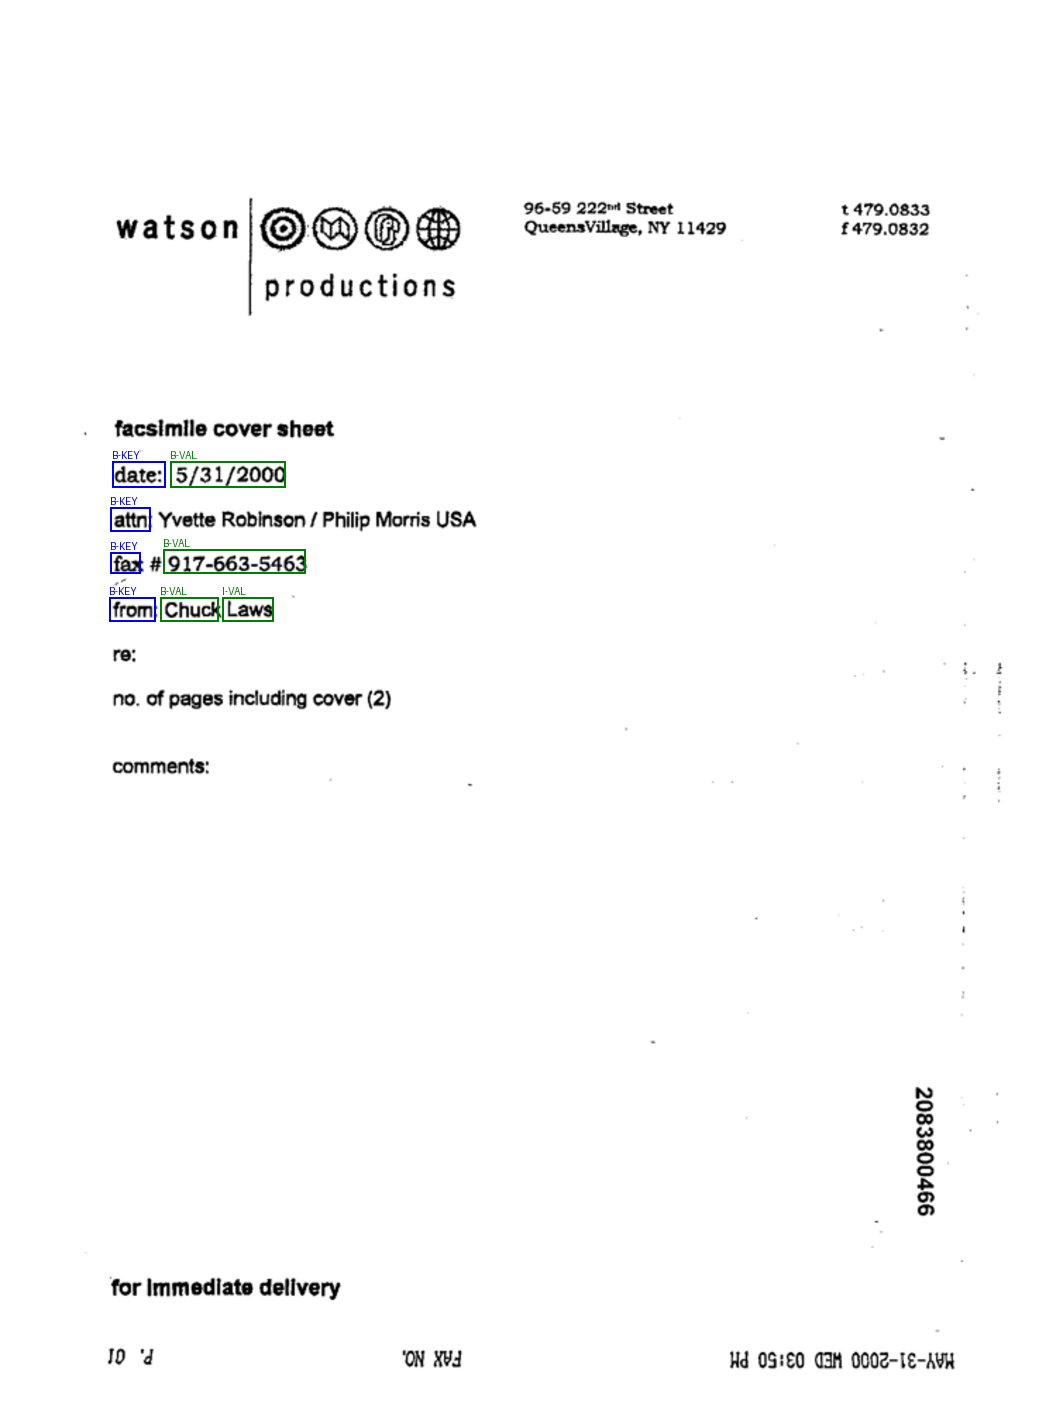

In [ ]:
import torch
from PIL import ImageDraw, ImageFont

raw_example = test_records[0]
image  = raw_example["image"].copy()
tokens = raw_example["tokens"]
bboxes = raw_example["bboxes"]
img_w, img_h = image.size

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

encoding = processor(
    image,
    tokens,
    boxes=bboxes,
    return_tensors="pt",
    truncation=True,
    padding="max_length",
)
encoding = {k: v.to(device) for k, v in encoding.items()}

with torch.no_grad():
    outputs = model(**encoding)

logits      = outputs.logits
predictions = logits.argmax(-1)[0].cpu().tolist()

encoding_for_mask = processor(
    image,
    tokens,
    boxes=bboxes,
    word_labels=[0] * len(tokens),
    return_tensors="pt",
    truncation=True,
    padding="max_length",
)
label_mask = encoding_for_mask["labels"][0].tolist()

results = []
for pos, (pred_id, lbl) in enumerate(zip(predictions, label_mask)):
    if lbl == -100:
        continue
    bbox_norm = encoding["bbox"][0][pos].cpu().tolist()
    results.append((bbox_norm, id2label[pred_id]))

label2color = {"KEY": "blue", "VAL": "green", "other": "violet"}
draw = ImageDraw.Draw(image)

for (nx0, ny0, nx1, ny1), pred_str in results:
    if pred_str == "O":
        continue
    px0   = int(nx0 / 1000 * img_w)
    py0   = int(ny0 / 1000 * img_h)
    px1   = int(nx1 / 1000 * img_w)
    py1   = int(ny1 / 1000 * img_h)
    role  = pred_str.split("-", 1)[-1] if "-" in pred_str else "other"
    color = label2color.get(role, label2color["other"])
    draw.rectangle([px0, py0, px1, py1], outline=color, width=2)
    draw.text((px0, max(py0 - 12, 0)), pred_str, fill=color)

display(image)


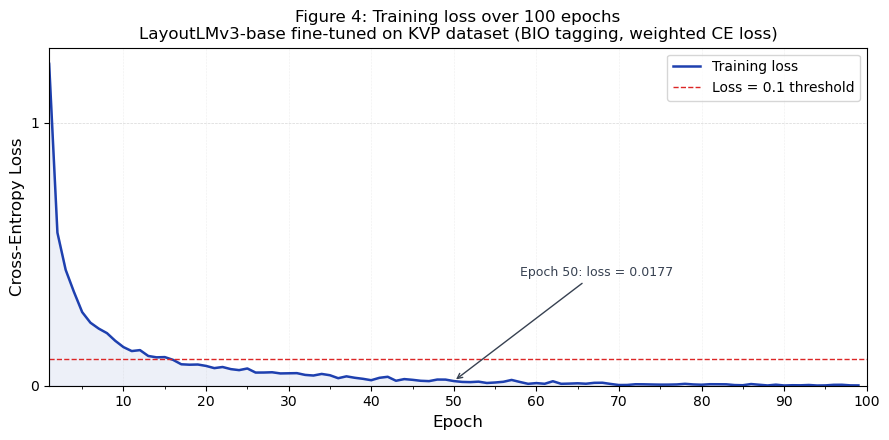

Epoch 1 loss : 1.2242
Epoch 20 loss : 0.0753
Epoch 50 loss : 0.0177
Epoch 100 loss : n/a (only 99 epochs logged)


In [19]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

state_path = r"C:\WORK\UTS\Autumn 2026\DEEPLEARNING\Assignment 3\layoutlmv3-finetuned-kvp-v3\checkpoint-25600\trainer_state.json"
with open(state_path) as f:
    log_history = json.load(f)["log_history"]

train_entries = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
epochs = [e for e, _ in train_entries]
losses = [l for _, l in train_entries]

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(epochs, losses, linewidth=1.8, color="#1e40af", label="Training loss")
ax.axhline(y=0.1, color="#dc2626", linewidth=1.0, linestyle="--", label="Loss = 0.1 threshold")
ax.fill_between(epochs, losses, alpha=0.08, color="#1e40af")

ax.set_xlabel("Epoch", fontsize=12)
ax.set_ylabel("Cross-Entropy Loss", fontsize=12)
ax.set_title("Figure 4: Training loss over 100 epochs\n"
             "LayoutLMv3-base fine-tuned on KVP dataset (BIO tagging, weighted CE loss)",
             fontsize=12)
ax.set_xlim(1, 100)
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(ticker.MultipleLocator(10))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax.grid(axis="x", linestyle=":", linewidth=0.4, alpha=0.4)


if len(losses) >= 50:
    ep50_loss = losses[49]
    ax.annotate(
        f"Epoch 50: loss = {ep50_loss:.4f}",
        xy=(50, ep50_loss),
        xytext=(58, ep50_loss + 0.4),
        fontsize=9,
        arrowprops=dict(arrowstyle="->", color="#374151", lw=1.0),
        color="#374151",
    )

ax.legend(fontsize=10, loc="upper right")
fig.tight_layout()
plt.savefig("training_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

def _print_epoch_loss(epoch_num):
    idx = epoch_num - 1
    if idx < len(losses):
        print(f"Epoch {epoch_num} loss : {losses[idx]:.4f}")
    else:
        print(f"Epoch {epoch_num} loss : n/a (only {len(losses)} epochs logged)")

for epoch_num in (1, 20, 50, 100):
    _print_epoch_loss(epoch_num)
